# Breast Cancer Detection Using CNN

**IDC classification using keras**

In [ ]:
from glob import glob
from keras.preprocessing.image import load_img, img_to_array

Using TensorFlow backend.


In [ ]:
import pandas as pd
import numpy as np
import keras
import matplotlib.pyplot as plt
import os

In [ ]:
files = glob('/kaggle/input/breast-histopathology-images/*/*/*')

In [ ]:
count =0
for file in files:
    if file[-5] == '1':
        count+=1
print(count)

78838


In [ ]:
len(files)

278082

In [ ]:
def show_img(files):
    plt.figure(figsize= (10,10))
    ind = np.random.randint(0, len(files), 25)
    i=0
    for loc in ind:
        plt.subplot(5,5,i+1)
        sample = load_img(files[loc], target_size=(150,150))
        sample = img_to_array(sample)
        plt.axis("off")
        plt.imshow(sample.astype("uint8"))
        i+=1

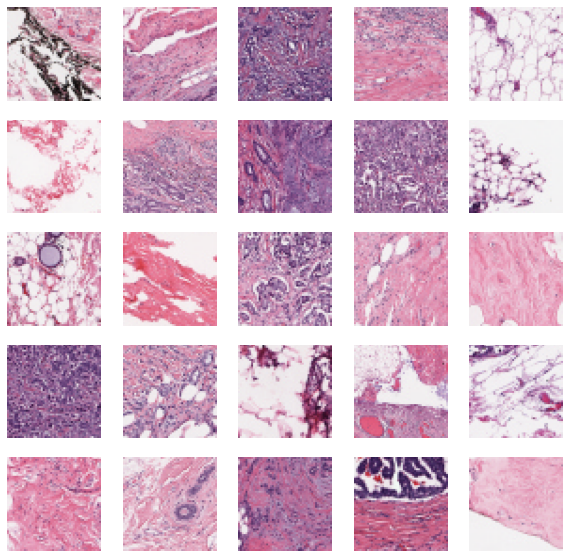

In [ ]:
show_img(files)

In [ ]:
def load_data(files, lower_limit, upper_limit):
    X = []
    y = []
    for file in files[lower_limit:upper_limit]:
        if file.endswith(".png"):
            img = load_img(file, target_size = (50,50))
            pixels = img_to_array(img)
            pixels /= 255
            X.append(pixels)
            if(file[-5] == '1'):
                y.append(1)
            elif(file[-5] == '0'):
                y.append(0)
    return np.stack(X), y



In [ ]:
from sklearn.model_selection import train_test_split
#Splitting the data into training set
X_train,y_train = load_data(files,0, 90000)

In [ ]:
import seaborn as sns

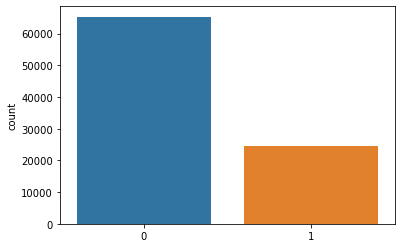

In [ ]:
sns.countplot(y_train)

In [ ]:
X_test, y_test = load_data(files, 90000, 110000)

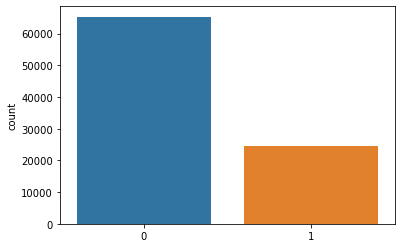

In [ ]:
sns.countplot(y_train)

## Handling Class Imbalance Problem

In [ ]:
files[:5]

['/kaggle/input/breast-histopathology-images/10295/0/10295_idx5_x1351_y1101_class0.png',
 '/kaggle/input/breast-histopathology-images/10295/0/10295_idx5_x1501_y501_class0.png',
 '/kaggle/input/breast-histopathology-images/10295/0/10295_idx5_x1501_y1101_class0.png',
 '/kaggle/input/breast-histopathology-images/10295/0/10295_idx5_x451_y901_class0.png',
 '/kaggle/input/breast-histopathology-images/10295/0/10295_idx5_x801_y451_class0.png']

In [ ]:
def load_balanced_data(files, size, start_index):
    half_size = int(size/2)
    count=0
    res = []
    y = []
    for file in files[start_index:]:
        if (count!=half_size):
            if file[-5] == '1' and file.endswith(".png"):
                img = load_img(file, target_size = (50,50))
                pixels = img_to_array(img)
                pixels /= 255
                res.append(pixels)
                y.append(1)
                count += 1

    for file in files[start_index:]:
        if(count!=0):
            if(file[-5] == '0'):
                img = load_img(file, target_size = (50,50))
                pixels = img_to_array(img)
                pixels /= 255
                res.append(pixels)
                y.append(0)
                count -= 1
    return np.stack(res), y



In [ ]:
X_train2, y_train2 = load_balanced_data(files, 90000,0)

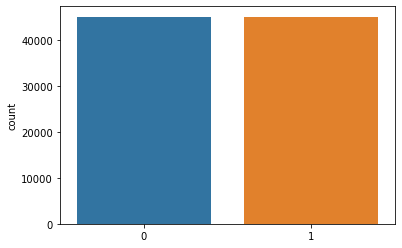

In [ ]:
sns.countplot(y_train2)

In [ ]:
x_test2, y_test2 = load_balanced_data(files, 20000, 100000)

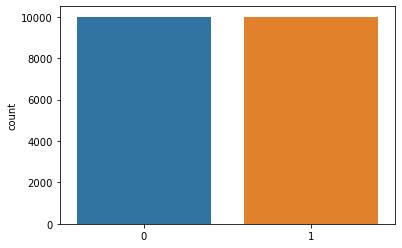

In [ ]:
sns.countplot(y_test2)